In [74]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
# sparse simulation
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import os

from ghd_module import *
from dynamics_module import *

<unknown>:302: SyntaxWarning: invalid escape sequence '\c'
<unknown>:310: SyntaxWarning: invalid escape sequence '\z'
<unknown>:331: SyntaxWarning: invalid escape sequence '\z'
<unknown>:351: SyntaxWarning: invalid escape sequence '\z'
<unknown>:368: SyntaxWarning: invalid escape sequence '\z'
<unknown>:302: SyntaxWarning: invalid escape sequence '\c'
<unknown>:310: SyntaxWarning: invalid escape sequence '\z'
<unknown>:331: SyntaxWarning: invalid escape sequence '\z'
<unknown>:351: SyntaxWarning: invalid escape sequence '\z'
<unknown>:368: SyntaxWarning: invalid escape sequence '\z'


In [73]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
def ensure_directory_exists(home):
    if not os.path.exists(home):
        os.makedirs(home)

<class 'numpy.linalg.LinAlgError'>


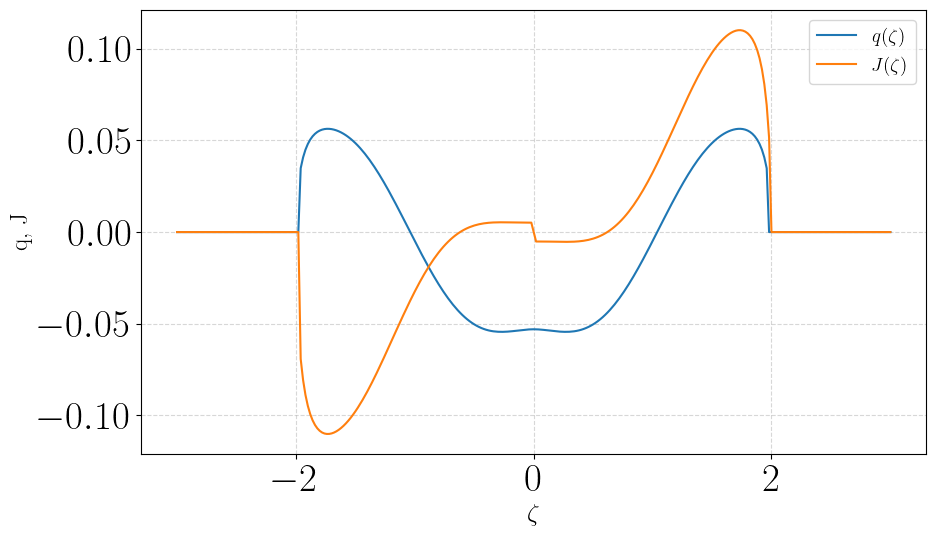

In [56]:
############################################################
# 5.  EXAMPLE: PURE GHD (no lattice)
############################################################

if __name__ == "__main__":
    # Parameters
    M = 5
    J = 1.0
    gamma = 1
    r = 3       # choose any integer
    sign = '-'  # or '-'

    # Solve for b_r
    r_vals, b_vals = solve_truncated_system_full(M, J, gamma)

    # \zeta-grid
    zMin, zMax = -3.0, 3.0
    nZ = 301
    zetas = np.linspace(zMin, zMax, nZ)

    # GHD profiles
    q_vals = np.array([hyd_charge(r, z, sign, r_vals, b_vals) for z in zetas])
    J_vals = np.array([hyd_current(r, z, sign, r_vals, b_vals) for z in zetas])

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(zetas, q_vals, label=r"$q(\zeta)$")
    plt.plot(zetas, J_vals, label=r"$J(\zeta)$")
    plt.xlabel(r"$ \zeta $", fontsize= 18)
    plt.ylabel("q, J", fontsize= 18)
    plt.grid(True, ls='--', alpha=0.5)
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.show()

    # Example: save data to CSV for later use
    # data = np.column_stack([zetas, q_vals, J_vals])
    # np.savetxt("ghd_profiles_r{}_M{}_gamma{}.csv".format(r, M, gamma),
    #            data, delimiter=",",
    #            header="zeta,q,J", comments="")

In [9]:
# Example
############################################################
# 5.  EXAMPLE: GHD and LATICE 
############################################################

if __name__ == "__main__":
    size = 400
    N = 2*size
    T1=1
    Mu=0
    BC= 'open'
    C0 = Gamma_0(size)                  # (N,N) dense
    vecC0 = mat2vec(C0)                 # (N^2, 1)
    h = Hamiltonian(size, T1, Mu, BC)  # (N,N) dense or sparse
    home_data = "/Users/juan/Desktop/Bologna/INH_QUENCH/"
    
    # Choose projector
    # P_centered = projector_centered_sp(L=size/2, size=size, bc='open', dtype=np.float64)
    
    # or prefix region A = [0, LA-1]:
    # P_left = projector_prefix_sp(LA=size, N=N, bc='open')
    
    # or prefix region A= [LA,N]
    P_right = projector_prefix_RIGHT_sp(LA= size, N=N, bc= BC)
    # Dense_P_right= projector_HZ(size, BC)
    
    #measurement rate
    gamma = 0
    # h_cond = 1j*h - gamma*P_centered            # NOTE: h_cond is (N,N), keep it sparse if possible
    h_cond=  1j*h - gamma*P_right# NOTE: h_cond is (N,N), keep it sparse if possible
    
    # Dense_h_cond= 1j*h - gamma*Dense_P_right
    # Build Liouvillian (sparse)
    # L_sup = liouvillian_sp(h_cond, P_centered, gamma)
    
    L_sup = liouvillian_sp(h_cond, P_right, gamma)
    
    # Dense_L_sup = liouvillian(Dense_h_cond, Dense_P_right, gamma)
    print('done', N)
    # P_right.toarray()

    # Times
    T = np.arange(0, 20*np.pi, 0.5)
    
    # Evolve without dense expm
    vecC_t = evolve_vec_expm_multiply(L_sup, vecC0, T)  # shape (len(T), N^2, 1)
    print('done with time evolution')

    

done 800
done with time evolution


1

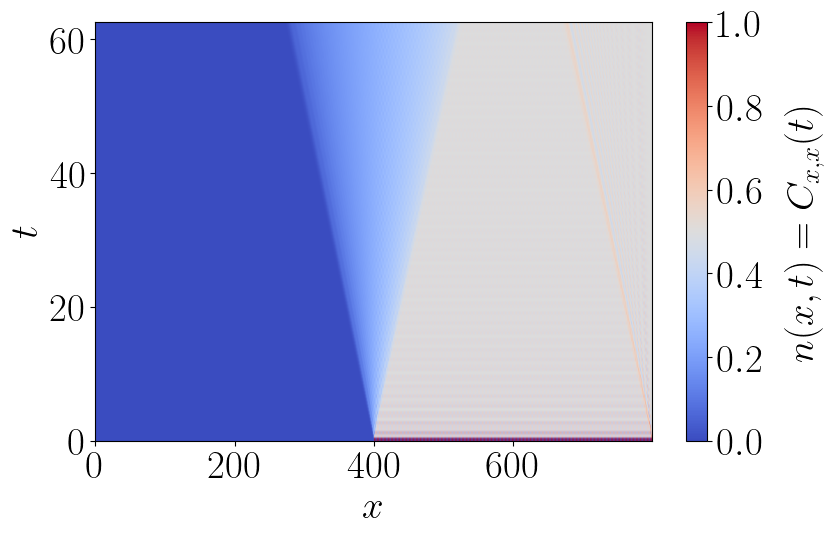

In [57]:
# If you have a time array t of length T (like your earlier code):
fig, ax = plot_density_heatmap(vecC_t, t_axis=T, cmap="coolwarm",vmin=0.0, vmax=1.0, \
                               cbar_label=r"$n(x,t)=C_{x,x}(t)$",yticks=None)
# ax.set_ylim(0,50*np.pi)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 28,
})
# Save the figure as PDF  

ensure_directory_exists(home_data)
# plt.savefig(home_data + f"NE_Transport_{size}_Gamma{gamma}_L{L}.png", format='png', bbox_inches='tight', dpi=300)
# plt.savefig(home_data + f"NE_Transport_{size}_Gamma{gamma}_L{size}_BC_{BC}.png", format='png', bbox_inches='tight', dpi=300)
# plt.savefig(home_data + f"Cent_NE_Trans_{size}_Gamma{gamma}_L{size}_BC_{BC}.png", format='png', bbox_inches='tight', dpi=300)
gamma

        
        

In [75]:
#charge number
r= 1
sgn= '-'
q_lat = np.array([qm_symm(r, xx, C_zeta, bc).real for xx in range(N)])
J_lat = np.array([jm_symm(r, xx, C_zeta, bc).real for xx in range(N)])


NameError: name 'qm_symm' is not defined